In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("student_performance_dataset.csv")

In [4]:
df.head()

,Student_ID,Study_Hours,Attendance,Assignments,Previous_Marks,Discipline,Pass
0,101,2,60,55,50,65,0
1,102,3,65,58,55,70,0
2,103,4,70,60,60,72,0
3,104,5,75,68,65,75,1
4,105,6,80,72,70,80,1


In [5]:
df.shape

(30, 7)

In [6]:
df.columns

Index(['Student_ID', 'Study_Hours', 'Attendance', 'Assignments',
       'Previous_Marks', 'Discipline', 'Pass'],
      dtype='str')

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Student_ID      30 non-null     int64
 1   Study_Hours     30 non-null     int64
 2   Attendance      30 non-null     int64
 3   Assignments     30 non-null     int64
 4   Previous_Marks  30 non-null     int64
 5   Discipline      30 non-null     int64
 6   Pass            30 non-null     int64
dtypes: int64(7)
memory usage: 1.8 KB


In [8]:
df.describe()

,Student_ID,Study_Hours,Attendance,Assignments,Previous_Marks,Discipline,Pass
count,30.000000,30.000000,30.000000,30.0000,30.000000,30.000000,30.000000
mean,115.500000,4.800000,75.066667,68.5000,66.233333,77.033333,0.633333
std,8.803408,2.023994,9.895779,9.8777,10.367999,7.819001,0.490133
min,101.000000,1.000000,55.000000,50.0000,45.000000,60.000000,0.000000
25%,108.250000,3.000000,67.250000,60.0000,58.250000,71.250000,0.000000
50%,115.500000,5.000000,76.500000,69.5000,67.000000,78.000000,1.000000
75%,122.750000,6.000000,82.750000,75.7500,73.750000,82.750000,1.000000
max,130.000000,8.000000,91.000000,86.0000,85.000000,91.000000,1.000000


In [9]:
df.isnull().sum()

Student_ID        0
Study_Hours       0
Attendance        0
Assignments       0
Previous_Marks    0
Discipline        0
Pass              0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.corr(numeric_only=True)

,Student_ID,Study_Hours,Attendance,Assignments,Previous_Marks,Discipline,Pass
Student_ID,1.000000,0.156757,0.268368,0.286902,0.299403,0.310843,0.259729
Study_Hours,0.156757,1.000000,0.980303,0.979682,0.981664,0.974413,0.827287
Attendance,0.268368,0.980303,1.000000,0.988472,0.992656,0.992894,0.858353
Assignments,0.286902,0.979682,0.988472,1.000000,0.995472,0.992285,0.844017
Previous_Marks,0.299403,0.981664,0.992656,0.995472,1.000000,0.996943,0.831698
Discipline,0.310843,0.974413,0.992894,0.992285,0.996943,1.000000,0.831098
Pass,0.259729,0.827287,0.858353,0.844017,0.831698,0.831098,1.000000


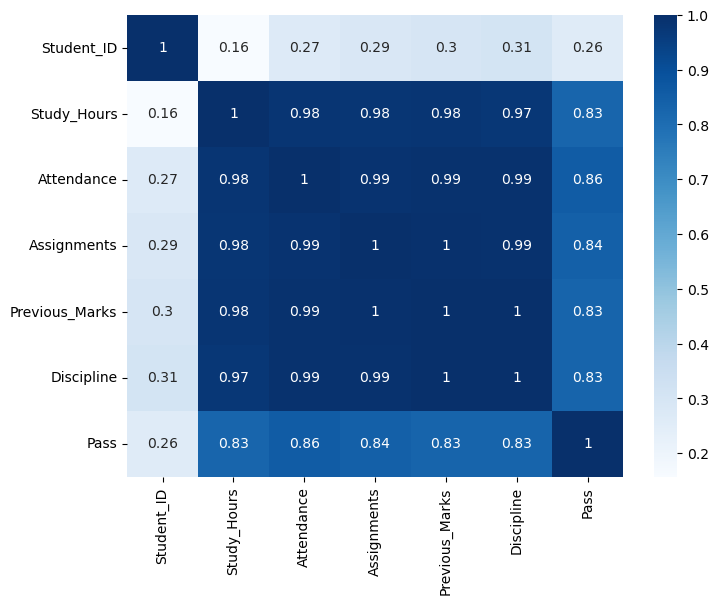

In [12]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap="Blues")
plt.show()

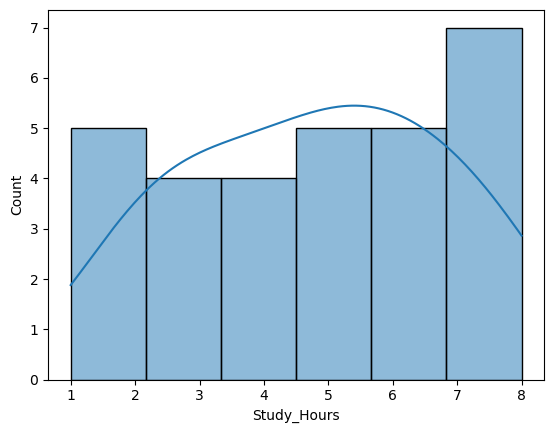

In [13]:
sns.histplot(df["Study_Hours"],kde=True)
plt.show()

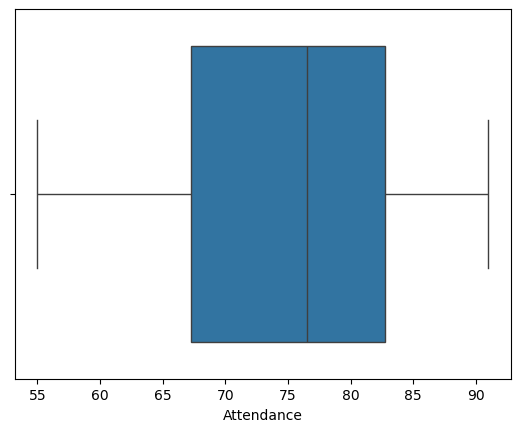

In [14]:
sns.boxplot(x=df["Attendance"])
plt.show()

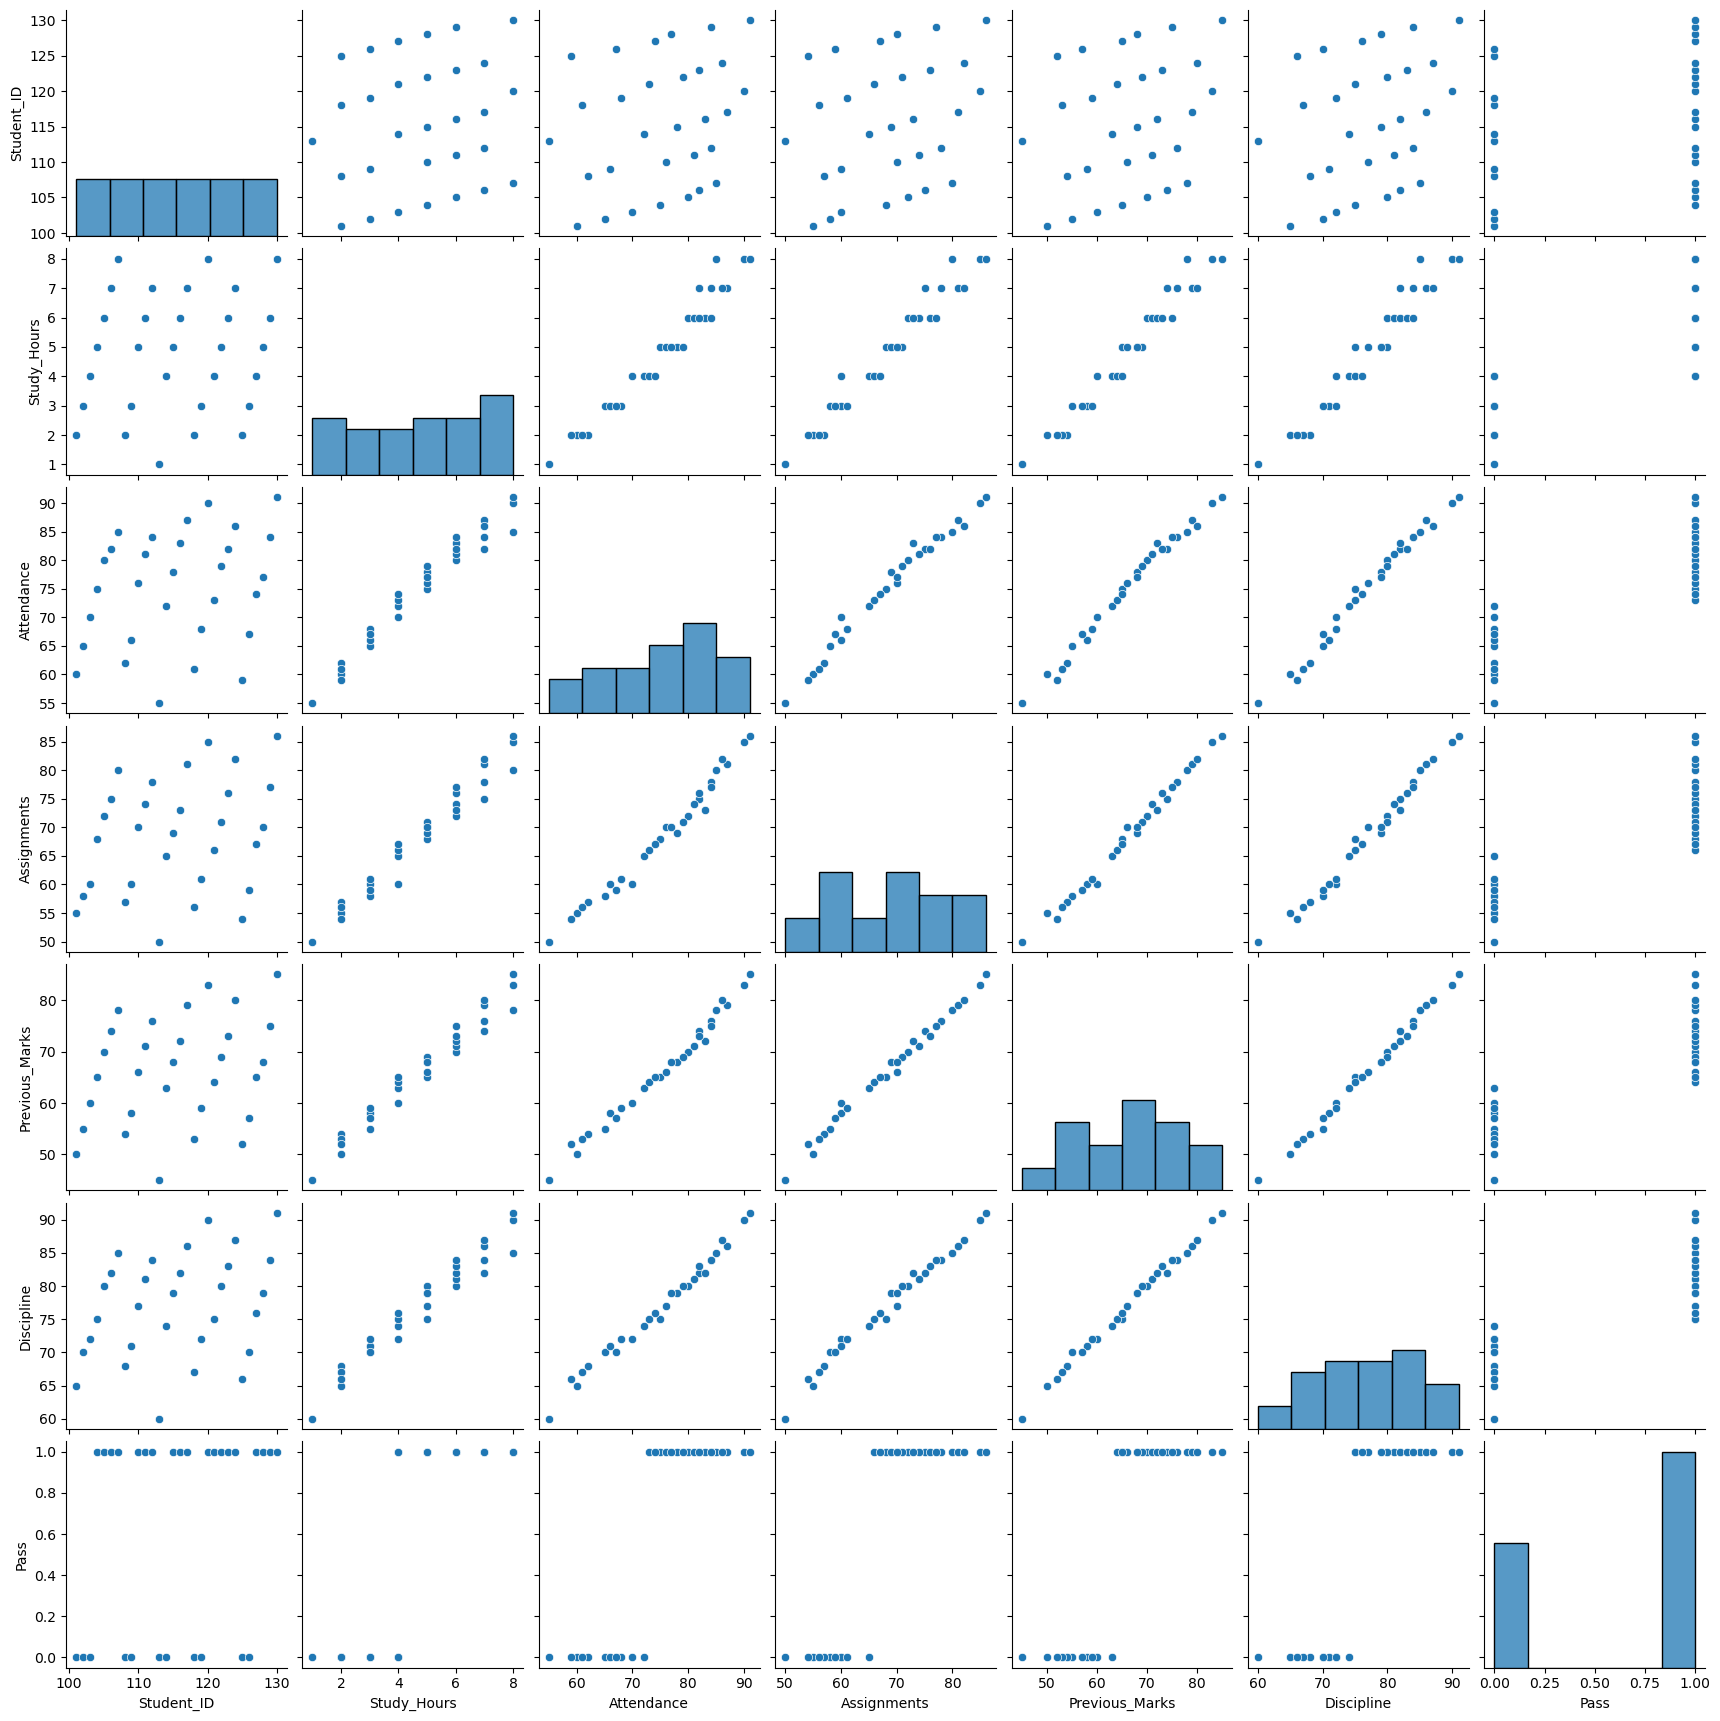

In [15]:
sns.pairplot(df)
plt.show()

In [16]:
X = df.drop(["Student_ID","Pass"],axis=1)

y = df["Pass"]

In [17]:
from sklearn.model_selection import train_test_split

In [18]:
X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [19]:
from sklearn.ensemble import RandomForestClassifier

In [20]:
model = RandomForestClassifier()

In [21]:
model.fit(X_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [22]:
y_pred = model.predict(X_test)

In [23]:
print(y_pred)

[1 1 1 0 0 1]


In [24]:
comparison = pd.DataFrame({
    "Actual":y_test,
    "Predicted":y_pred
})

comparison

,Actual,Predicted
27,1,1
15,1,1
23,1,1
17,0,0
8,0,0
9,1,1


In [25]:
from sklearn.metrics import accuracy_score

In [26]:
accuracy = accuracy_score(y_test,y_pred)

print(accuracy)

1.0


In [27]:
print("Accuracy :",accuracy)

Accuracy : 1.0


In [28]:
from sklearn.metrics import confusion_matrix

In [29]:
cm = confusion_matrix(y_test,y_pred)

print(cm)

[[2 0]
 [0 4]]


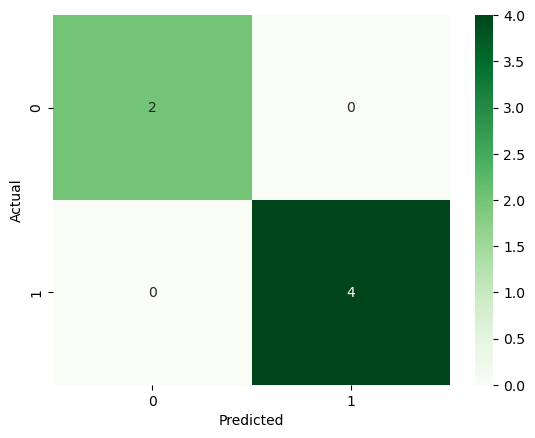

In [30]:
sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Greens")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [31]:
from sklearn.metrics import classification_report

In [32]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         4

    accuracy                           1.00         6
   macro avg       1.00      1.00      1.00         6
weighted avg       1.00      1.00      1.00         6



In [33]:
importance = pd.DataFrame({
    "Feature":X.columns,
    "Importance":model.feature_importances_
})

importance

,Feature,Importance
0,Study_Hours,0.04
1,Attendance,0.27
2,Assignments,0.24
3,Previous_Marks,0.30
4,Discipline,0.15


In [34]:
importance.sort_values(by="Importance",ascending=False)

,Feature,Importance
3,Previous_Marks,0.30
1,Attendance,0.27
2,Assignments,0.24
4,Discipline,0.15
0,Study_Hours,0.04


In [35]:
importance = importance.sort_values(by="Importance")

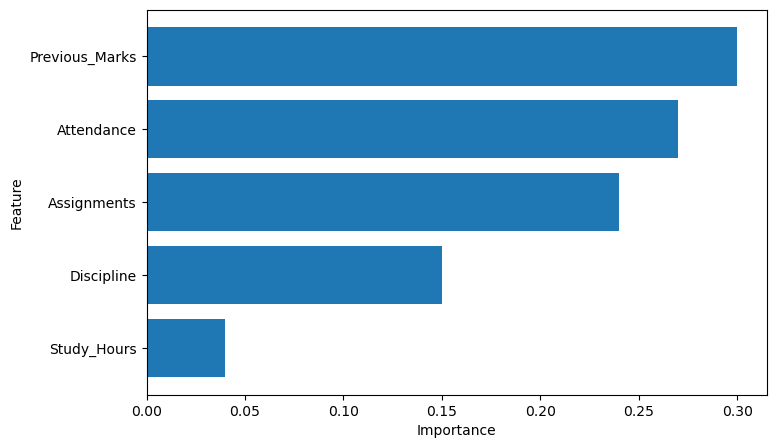

In [36]:
plt.figure(figsize=(8,5))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

In [37]:
new_student = [[6,85,78,75,82]]

In [38]:
prediction = model.predict(new_student)

print(prediction)

[1]


In [39]:
import joblib

joblib.dump(model,"random_forest_model.pkl")

['random_forest_model.pkl']